In [3]:
import sys; sys.path.insert(0, "..")
import numpy as np 
from datasets import load_from_disk 
from collections import Counter 
from omegaconf import OmegaConf 

cfg = OmegaConf.load("../configs/train_config.yaml")
raw = load_from_disk("../data/processed/raw_combined")
train_ds = raw["train"]

durations, word_counts, sample_rates = [], [], []
for sample in train_ds.select(range(min(3000, len(train_ds)))):
    arr = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"] 
    durations.append(len(arr) / sr)
    word_counts.append(len(sample["sentence"].split()))
    sample_rates.append(sr)

durations = np.array(durations)
word_counts = np.array(word_counts)

print(f"Total samples: {len(train_ds)}")
print(f"Duration Mean: {durations.mean()}")
print(f"Duration Median: {np.median(durations)}")
print(f"Words/clip mean: {word_counts.mean()}")
print(f"Empty transcripts: {sum(1 for s in train_ds['sentence'] if not s.strip())}")
print(f"Sample rates seen: {Counter(sample_rates).most_common()}")


Total samples: 107493
Duration Mean: 4.107772
Duration Median: 3.6265
Words/clip mean: 6.0
Empty transcripts: 0
Sample rates seen: [(16000, 3000)]


/tmp/ipykernel_57939/1126823952.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


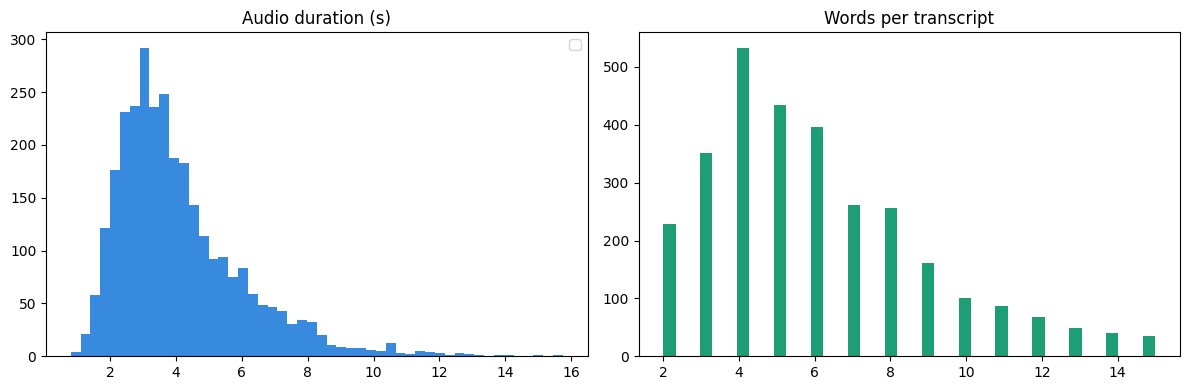

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(durations, bins=50, color="#378ADD")
axes[0].set_title("Audio duration (s)")
axes[0].legend()
axes[1].hist(word_counts, bins=40, color="#1D9E75")
axes[1].set_title("Words per transcript")
plt.tight_layout(); plt.show()